In [3]:
# Reinstall fastai to ensure latest version
!pip install fastai --quiet

from fastai.text.all import *
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
# Download and prepare Yelp dataset
print("Downloading Yelp Polarity dataset...")
dataset = load_dataset('yelp_polarity')

train_data = dataset['train'].to_pandas()
test_data  = dataset['test'].to_pandas()

# Sample 5,000 positive and 5,000 negative from train
train_pos = train_data[train_data['label'] == 1].sample(5000, random_state=42)
train_neg = train_data[train_data['label'] == 0].sample(5000, random_state=42)
train_subset = pd.concat([train_pos, train_neg]).sample(frac=1, random_state=42)

# Sample 2,000 positive and 2,000 negative from test
test_pos = test_data[test_data['label'] == 1].sample(2000, random_state=42)
test_neg = test_data[test_data['label'] == 0].sample(2000, random_state=42)
test_subset = pd.concat([test_pos, test_neg]).sample(frac=1, random_state=42)

print(f"Train subset: {len(train_subset)} reviews")
print(f"Test subset:  {len(test_subset)} reviews")
print(f"Label distribution (train):\n{train_subset['label'].value_counts()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/256M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/560000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/38000 [00:00<?, ? examples/s]

Train subset: 10000 reviews
Test subset:  4000 reviews
Label distribution (train):
label
0    5000
1    5000
Name: count, dtype: int64


In [5]:
base_path = Path('yelp_data')

for split, df in [('train', train_subset), ('test', test_subset)]:
    for label, name in [(1, 'pos'), (0, 'neg')]:
        folder = base_path/split/name
        folder.mkdir(parents=True, exist_ok=True)
        subset = df[df['label'] == label]
        for i, (_, row) in enumerate(subset.iterrows()):
            (folder/f'{i}.txt').write_text(row['text'])

print("Data saved to folder structure")
print(f"Contents: {list(base_path.iterdir())}")

Data saved to folder structure
Contents: [Path('yelp_data/train'), Path('yelp_data/test')]


In [6]:
# Prepare language model dataloader
dls_lm = TextDataLoaders.from_folder(
    base_path,
    is_lm=True,
    valid_pct=0.1,
    seed=42,
    bs=32
)

print(f"Vocabulary size: {len(dls_lm.vocab)}")
dls_lm.show_batch(max_n=2)

Vocabulary size: 15952
xxbos i have experienced better , actually . 

 i mean , just walking this place and you can feel something is missing . xxmaj it for sure needs renovation . 

 xxmaj it 's really not fair . xxmaj this place opened in the 50 's and you can tell it 's iconic and has had many stars and amazing people walk through it 's halls . 

 xxmaj however ,
for a comparable fare , its a much better buffet and a much finer experience . xxbos xxmaj everyone seems to be reviewing this place so i decided throw my experience in . xxmaj actually i went into this store for the first time ever today after reading the rather amusing opinions about this place . 
 xxmaj they have a variety of underwear and bras , some normal others just plain
i have experienced better , actually . 

 i mean , just walking this place and you can feel something is missing . xxmaj it for sure needs renovation . 

 xxmaj it 's really not fair . xxmaj this place opened in the 50 's and you can tell it 's icon

In [7]:
# Fine-tune language model
learn_lm = language_model_learner(
    dls_lm,
    AWD_LSTM,
    drop_mult=0.3,
    metrics=[accuracy, Perplexity()]
)

learn_lm.fine_tune(1, 1e-2)

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:13&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,perplexity,time
0,4.049603,3.962179,0.274246,52.571751,02:23


epoch,train_loss,valid_loss,accuracy,perplexity,time
0,3.719925,3.745776,0.297041,42.341839,02:56


In [8]:
# Save language model encoder
learn_lm.save_encoder('yelp_enc')
print("Encoder saved")

Encoder saved


In [10]:
# Prepare classifier dataloader
dls_cls = TextDataLoaders.from_folder(
    base_path,
    valid='test',
    text_vocab=dls_lm.vocab,
    bs=32
)

print(f"Train size: {len(dls_cls.train_ds)}")
print(f"Validation size: {len(dls_cls.valid_ds)}")
dls_cls.show_batch(max_n=3)

Train size: 10000
Validation size: 4000


,text,category
0,"xxbos xxmaj one xxup epic xxup fail from start to finish xxrep 3 ! \n▁\n xxmaj so , i called the hotel at noon on my day of check in to let them know that i would be there at midnight . xxmaj our drive from xxmaj newport to xxmaj vegas was quick and painless , got some xxmaj in and xxmaj out and was ready for a fun fun night in xxmaj vegas . xxmaj we pull up at the hotel at midnight and guess what … go to check in . "" "" oh we 're sorry , the hotel is sold out . xxmaj we 'll give you this non - hrh room plus $ 200 food and beverage and waive your resort charges "" "" . xxmaj fine , xxup fail ! xxmaj go to the room and what a scary sight . xxmaj like something",neg
1,"xxbos xxmaj the staff are polite and courteous until you make your purchase . xxmaj after they have your money they treat you like a second class citizen and blow you off even though your concern is legitimate . \n\n i purchased a xxunk massage chair that sells for over $ 5 , xxrep 3 0 after taxes . i paid in full … no financing or anything . \n\n xxmaj they sent two delivery men to setup and install the chair . xxmaj one of them must have been having a horrible day because he was pretty rude to me as well as his coworker . i should mention his eyes were very xxunk , but he did not smell like drugs or alcohol . \n\n xxmaj they spent roughly an hour setting it up . xxmaj as soon as they left i inspected the chair and found they",neg
2,"xxbos xxmaj i 'm not a xxmaj las xxmaj vegas local , and on my trip there last night , a well - meaning acquaintance sent me out to xxmaj summerlin to find an old xxunk manned by xxunk . i could n't find the place ( xxunk address , incomplete directions ) , and i ended up somewhat lost , a little cold , and very , very hungry . xxmaj so i fired up the heater in the rental car , xxmaj yelped nearby businesses with my smartphone , and ended up deciding to hit xxmaj rosati 's pizza . xxmaj after all , the rating was a solid 4 stars . \n\n▁ xxmaj rosati 's is located on what seems to be a major road through xxmaj summerlin , and its clientele are pleasingly non - threatening family types of a few different colors who have the",neg


In [11]:
# Fine-tune classifier
learn_cls = text_classifier_learner(
    dls_cls,
    AWD_LSTM,
    drop_mult=0.5,
    metrics=accuracy
)

learn_cls.load_encoder('yelp_enc')
learn_cls.fine_tune(2, 1e-2, freeze_epochs=2)

epoch,train_loss,valid_loss,accuracy,time
0,0.324146,0.234976,0.914500,00:52
1,0.313101,0.231499,0.904250,00:49


epoch,train_loss,valid_loss,accuracy,time
0,0.248766,0.166525,0.933750,01:47
1,0.174886,0.155875,0.942000,01:47


In [21]:
# Evaluate ULMFiT classifier
preds, targets, decoded = learn_cls.get_preds(with_decoded=True)
ulmfit_acc = accuracy_score(targets, decoded)
print(f"\nULMFiT Accuracy: {ulmfit_acc:.4f}")

# Show sample predictions by reading directly from saved text files
label_names = dls_cls.vocab
test_files  = list((base_path/'test'/'pos').iterdir())[:3] + \
              list((base_path/'test'/'neg').iterdir())[:2]
true_map    = {'pos': 'pos', 'neg': 'neg'}

print("\nSample Predictions:")
print(f"{'Review':<60} {'True':>6} {'Predicted':>10}")
print("-" * 80)
for i, f in enumerate(test_files[:5]):
    text      = f.read_text(encoding='utf-8', errors='ignore')[:57] + "..."
    true_lbl  = f.parent.name
    pred_lbl  = 'pos' if int(decoded[i]) == 1 else 'neg'
    print(f"{text:<60} {true_lbl:>6} {pred_lbl:>10}")


ULMFiT Accuracy: 0.9420

Sample Predictions:
Review                                                         True  Predicted
--------------------------------------------------------------------------------
Have stayed here about 3 times.  Rooms are pretty awesome...    pos        pos
My friends and I are vegetarians that enjoy trying intere...    pos        pos
I love this place!! The food is always fantastic. The cla...    pos        pos
12/03/12\n\nHmm... I could've sworn I had written a revie...    neg        pos
$5.99 breakfast steak and eggs...\n\nTheir version of ste...    neg        pos


In [22]:
# Build and evaluate Naive Bayes
def load_texts(folder):
    texts, labels = [], []
    for label, val in [('pos', 1), ('neg', 0)]:
        p = Path(folder)/label
        for f in p.iterdir():
            texts.append(f.read_text(encoding='utf-8', errors='ignore'))
            labels.append(val)
    return texts, labels

train_texts, train_labels = load_texts(base_path/'train')
test_texts,  test_labels  = load_texts(base_path/'test')

vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_texts)
X_test  = vectorizer.transform(test_texts)

nb_model = MultinomialNB()
nb_model.fit(X_train, train_labels)

nb_preds = nb_model.predict(X_test)
nb_acc   = accuracy_score(test_labels, nb_preds)

print(f"\nNaive Bayes Accuracy: {nb_acc:.4f}")
print("\nClassification Report:")
print(classification_report(test_labels, nb_preds,
                             target_names=['Negative', 'Positive']))


Naive Bayes Accuracy: 0.9020

Classification Report:
              precision    recall  f1-score   support

    Negative       0.90      0.91      0.90      2000
    Positive       0.91      0.90      0.90      2000

    accuracy                           0.90      4000
   macro avg       0.90      0.90      0.90      4000
weighted avg       0.90      0.90      0.90      4000



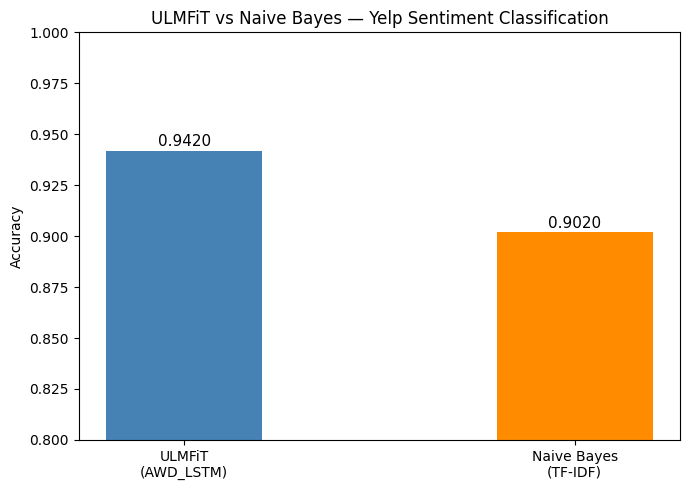


Accuracy difference: 4.00 percentage points in favor of ULMFiT


In [23]:
# Model Comparison
models = ['ULMFiT\n(AWD_LSTM)', 'Naive Bayes\n(TF-IDF)']
scores = [ulmfit_acc, nb_acc]
colors = ['steelblue', 'darkorange']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, scores, color=colors, width=0.4)
plt.ylim(0.8, 1.0)
plt.ylabel('Accuracy')
plt.title('ULMFiT vs Naive Bayes — Yelp Sentiment Classification')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{score:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

print(f"\nAccuracy difference: {(ulmfit_acc - nb_acc)*100:.2f} percentage points in favor of ULMFiT")

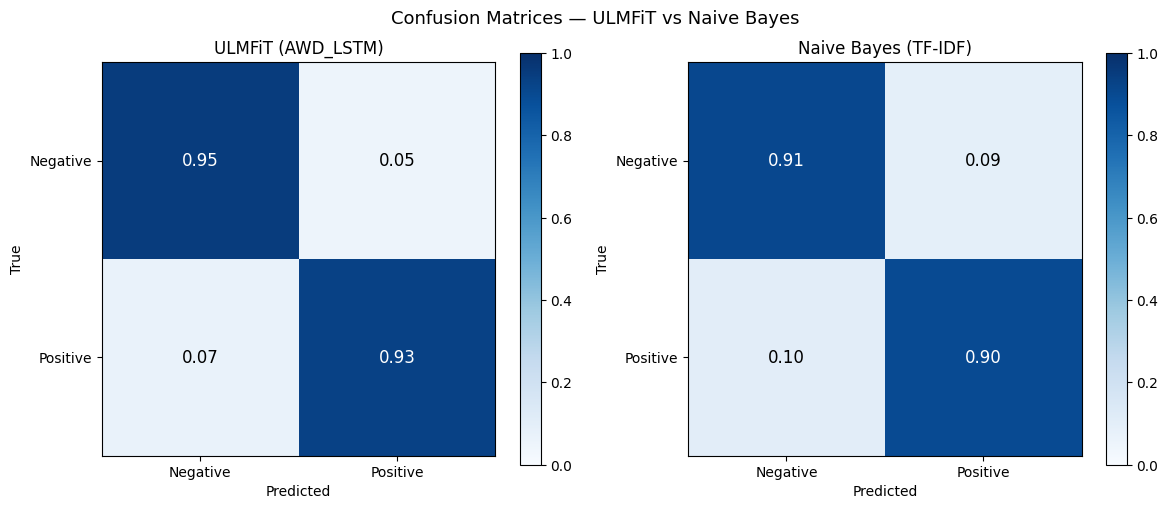

In [24]:
# Confusion matrices
from sklearn.metrics import confusion_matrix
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, title, y_true, y_pred in [
    (axes[0], 'ULMFiT (AWD_LSTM)', targets.numpy(), decoded.numpy()),
    (axes[1], 'Naive Bayes (TF-IDF)', test_labels, nb_preds)
]:
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Negative', 'Positive'])
    ax.set_yticklabels(['Negative', 'Positive'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm_norm[i,j]:.2f}',
                    ha='center', va='center',
                    color='white' if cm_norm[i,j] > 0.5 else 'black',
                    fontsize=12)

plt.suptitle('Confusion Matrices — ULMFiT vs Naive Bayes', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()